# Red de Hopfield

## Entorno de desarrollo

Este trabajo fue realizado en Google Colab utilizando la versión 3.13.15 de Python y las siguientes versiones de librerías externas:
* numpy 2.1.3
* matplotlib 3.10.0

## Librerías

In [1]:
# Descargar librerías externas
!pip install numpy==2.1.3 matplotlib==3.10.0 --quiet

In [2]:
# Importar librerías externas
import numpy as np
import matplotlib.pyplot as plt

## Contexto

Definiremos tres patrones binarios para que la red memorice. Estos patrones estarán en una matriz 6x6, y serán las letras:
* A
* T
* L

Calcularemos los pesos que debe tener cada conexión y pondremos a prueba la red introduciendo una de las letras pero con algo de ruido, para ver si la red de Hopfield converge en el patrón real.

## Definición de patrones

Definimos las letras como arrays de 36 elementos (en realidad serían matrices 6x6, pero para mayor facilidad de manejo los tratermos como arrays). Incluímos también una función de visualización de los patrones.

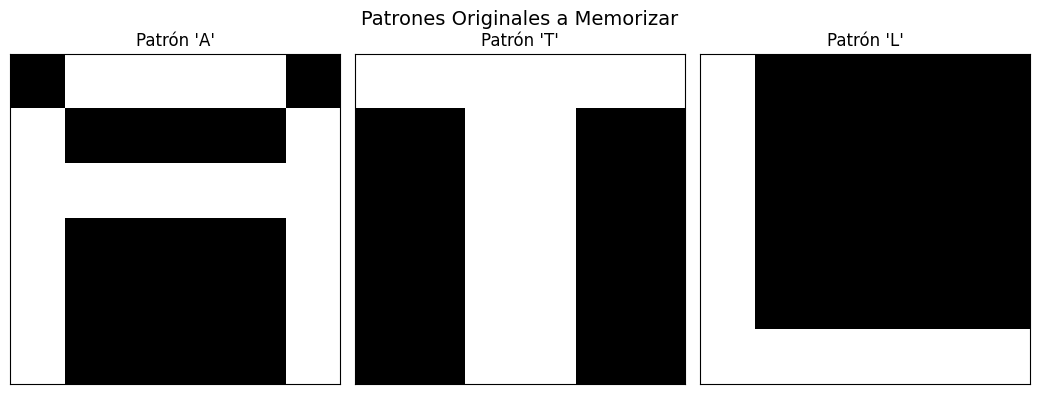

In [3]:
# Patrón letra A
letter_A = np.array([
    -1,  1,  1,  1,  1, -1,
     1, -1, -1, -1, -1,  1,
     1,  1,  1,  1,  1,  1,
     1, -1, -1, -1, -1,  1,
     1, -1, -1, -1, -1,  1,
     1, -1, -1, -1, -1,  1
])

# Patrón letra T
letter_T = np.array([
     1,  1,  1,  1,  1,  1,
    -1, -1,  1,  1, -1, -1,
    -1, -1,  1,  1, -1, -1,
    -1, -1,  1,  1, -1, -1,
    -1, -1,  1,  1, -1, -1,
    -1, -1,  1,  1, -1, -1
])

# Patrón letra L
letter_L = np.array([
     1, -1, -1, -1, -1, -1,
     1, -1, -1, -1, -1, -1,
     1, -1, -1, -1, -1, -1,
     1, -1, -1, -1, -1, -1,
     1, -1, -1, -1, -1, -1,
     1,  1,  1,  1,  1,  1
])

# Función para visualizar 1 o más patrones
def visualizar_patrones(vectores, titulos, titulo_principal=""):
    n_plots = len(vectores)
    fig, axes = plt.subplots(1, n_plots, figsize=(3.5 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    for ax, vector, titulo in zip(axes, vectores, titulos):
        ax.imshow(vector.reshape(6, 6), cmap='gray')
        ax.set_title(titulo)
        ax.set_xticks([])
        ax.set_yticks([])

    if titulo_principal:
        plt.suptitle(titulo_principal, fontsize=14)

    plt.tight_layout()
    plt.show()

# Ver patrones
visualizar_patrones(
    [letter_A, letter_T, letter_L],
    ["Patrón 'A'", "Patrón 'T'", "Patrón 'L'"],
    "Patrones Originales a Memorizar"
)

## ¿Cómo calcularemos W?

En una red de Hopfield, todas las neuronas están conectadas con todas. En este caso, como tenemos 36 neuronas, entonces vamos a tener una matriz W de tamaño 36x36, con la diagonal principal $w_{ii} = 0$ ya que las neuronas no están conectadas consigo mismas. Además, es una matriz simétrica, pues $w_{ij}=w_{ji}$, las conexiones son iguales en ambos sentidos.

Entonces, para calcular la matriz W, tendríamos que calcular sus elementos $w_{ij}$, los cuáles podemos calcularlos con:

$$w_{i,j} = \sum_{p=1}^{N} X_{i}^{p} \cdot X_{j}^{p} \text{ con } i \neq j$$

Siendo:
* p los patrones a memorizar.
* N la cantidad de patrones a memorizar.
* $X_i$ el valor de la casilla i en el patrón p
* $X_j$ el valor de la casilla j en el patrón p

Pero esto es para un solo elemento. Si prestamos atención, podemos plantear una única operación para calcular la matriz W de una, utilizando la siguiente fórmula:

$$W = \sum_{p=1}^{N} X^{p} (X^{p})^T \quad \text{con } w_{ii} = 0$$

Siendo:
* $X^p$ el vector del patrón p completo.

## Fase de recuperación

Básicamente le vamos a ingresar una entrada ruidosa a la red para que recupere el patrón original. Para recuperarlo, la red itera en un WHILE que finaliza cuando se cumple la condición de convergencia. En cada iteración, cada neurona asíncronamente se pregunta si debe cambiar de estado o mantenerse en el mismo. Cuando de una iteración a otra el estado de la red completa no cambia, ahí decimos que converge y que la red identificó un patrón. En cada iteración, todas las neuronas definen si cambian o no de estado siguiendo su suma neta la cuál pasa por una función de activación:

#### Función de suma neta
$$SN_i(t) = \sum_{j \neq i} w_{i,j} \cdot E_j(t)$$

#### Función de activación

$$F_i(t+1) = \begin{cases}
1 & \text{si } SN_i(t) > 0 \\
-1 & \text{si } SN_i(t) < 0 \\
S_i(t) & \text{si } SN_i(t) = 0
\end{cases}$$

## Implementación de la red de Hopfield

In [4]:
patterns = [letter_A, letter_T, letter_L]
n = letter_A.size

# Cálculo de W
W = np.zeros((n, n))           # Inicializo la matriz en 0
for p in patterns:
    W += np.outer(p, p)        # Voy sumando la multiplicación entre los elementos

np.fill_diagonal(W, 0)         # Transformo la diagonal principal en 0

# Para matrices grandes, es mejor normalizar los valores de W
# porque pueden quedar muy grandes con sumatorias tan largas
W /= n

def sumatoria_neta(pesos_i, estado):
    return np.dot(pesos_i, estado)

def funcion_activacion(sn, estado_anterior):
    if sn > 0:
        return 1
    elif sn < 0:
        return -1
    else:
        return estado_anterior

La red convergió en 2 épocas.



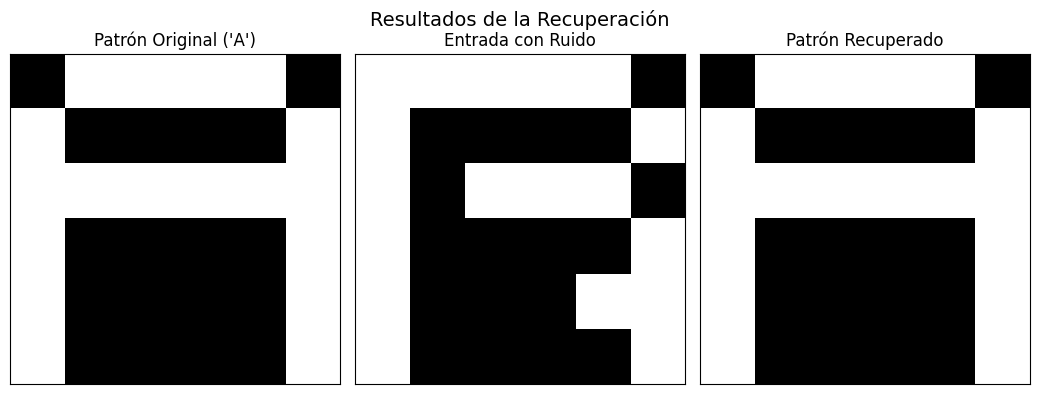


COMPROBACIÓN LÓGICA DE RESULTADOS VISUALES
¿Recuperó la letra A? True
¿Recuperó la letra T? False
¿Recuperó la letra L? False


In [5]:
# Fase de recuperación
def recuperar_patron(matriz_pesos, entrada_ruidosa, num_neuronas):
    state = entrada_ruidosa.copy()
    converged = False
    epocas = 0

    while not converged:
        previous_state = state.copy()
        for i in range(num_neuronas):
            sn = sumatoria_neta(matriz_pesos[i], state)   # Suma neta
            state[i] = funcion_activacion(sn, state[i])   # Función de activación

        if np.array_equal(state, previous_state):
            converged = True
        epocas += 1

    return state, epocas

# Creación de la entrada ruidosa a partir de la letra 'A'
noisy_A = letter_A.copy()
cantidad_ruido = 4
flip_indices = np.random.choice(n, size=cantidad_ruido, replace=False)   # Genera un vector con 6 números, del 1 al 36. Por ej: [2, 4, 20, 13, 9, 1]
noisy_A[flip_indices] *= -1

# Ejecutar fase de recuperación
state, epocas = recuperar_patron(W, noisy_A, n)

print(f"La red convergió en {epocas} épocas.\n")

# Visualización de resultados
visualizar_patrones(
    [letter_A, noisy_A, state],
    ["Patrón Original ('A')", "Entrada con Ruido", "Patrón Recuperado"],
    "Resultados de la Recuperación"
)

# Comprobación lógica
print("")
print("COMPROBACIÓN LÓGICA DE RESULTADOS VISUALES")
print("¿Recuperó la letra A?", np.array_equal(state, letter_A))
print("¿Recuperó la letra T?", np.array_equal(state, letter_T))
print("¿Recuperó la letra L?", np.array_equal(state, letter_L))

La red siempre encuentra el patrón original a partir de la entrada ruidosa.